# 采样与蒙特卡洛计算

学习目标：用伪随机样本估计期望与积分，解释误差和样本成本，并通过重复实验与选学的重要性采样核对估计条件。

前置知识：概率分布、期望、方差、大数定律、定积分；Python 函数、NumPy 数组。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；完整版本见环境说明。所有数据均为教学模拟，无需外部数据和网络请求。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 从加权求和到样本平均

设一次任务耗时 X 只可能为 1、2、5 秒，对应概率为 0.5、0.3、0.2。每次任务独立且服从同一分布，理论平均耗时为

$$\mu=E[X]=1\times0.5+2\times0.3+5\times0.2=2.1\text{ 秒}。$$

这个例子可以直接求和。若可能结果很多、求和或积分难以直接计算，可以按给定分布生成样本，再用平均值近似期望。这类利用随机样本计算近似结果的方法称为蒙特卡洛方法（Monte Carlo method）。样本平均与理论期望需要分开标记。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

durations = np.array([1.0, 2.0, 5.0])
probabilities = np.array([0.5, 0.3, 0.2])
exact_mean = np.sum(durations * probabilities)
rng_small = np.random.default_rng(2401)
small_sample = rng_small.choice(durations, size=12, p=probabilities)

print("理论平均耗时（秒）：", exact_mean)  # 预期约为 2.1。
print("12 次模拟耗时（秒）：", small_sample)  # 本次固定种子下为 [2. 1. 1. 1. 5. 5. 5. 1. 1. 1. 1. 2.]。
print("样本平均耗时（秒）：", small_sample.mean())  # 本次固定种子下约为 2.16667。
# 小样本均值会波动，不要求这 12 个数恰好按概率比例出现。

理论平均耗时（秒）： 2.1
12 次模拟耗时（秒）： [2. 1. 1. 1. 5. 5. 5. 1. 1. 1. 1. 2.]
样本平均耗时（秒）： 2.1666666666666665


## 2 伪随机数与复现条件

伪随机数由算法和内部状态确定。固定种子便于复现实验，但完整条件还包括相同的 BitGenerator、NumPy 构建、机器环境，以及同样的方法调用顺序和参数；跨版本或改变一次调用的数组大小，不保证逐项相同。

default_rng() 创建局部 Generator。random() 返回 [0,1) 内的浮点数，作为连续均匀分布的数值模拟；uniform(a, b) 模拟端点为 a、b 的均匀分布，其中 a<b。浮点舍入可能让 uniform() 返回上端点，因此不能把半开区间的实现描述当作所有数值运算中的严格保证。

In [2]:
first_rng = np.random.default_rng(2402)
second_rng = np.random.default_rng(2402)
first_draw = first_rng.random(5)
same_draw = second_rng.random(5)
next_draw = first_rng.random(5)

print("首批：", first_draw)  # 本次固定种子下约为 [0.523075 0.51157 0.0918462 0.915764 0.310913]。
print("相同条件重建生成器，首批相同：", np.array_equal(first_draw, same_draw))  # 预期 True；在相同条件下重建同一种子生成器会重现首批样本。
print("继续使用生成器的下一批：", next_draw)  # 本次固定种子下约为 [0.692117 0.769079 0.613134 0.213097 0.921058]。
# 后续调用推进状态；相同种子重建生成器则从相同起点重放。

首批： [0.52307535 0.51156979 0.09184617 0.91576425 0.31091259]
相同条件重建生成器，首批相同： True
继续使用生成器的下一批： [0.69211651 0.76907903 0.61313433 0.21309747 0.92105842]


重复实验需要新的随机抽样。在循环中反复用相同种子重建生成器，会重放同一批数，无法观察实验之间的随机波动。以下反例只用于说明这个差别。

本章的理论分析采用独立同分布（i.i.d.）模型，使用一个生成器持续取数来模拟。固定种子本身不证明独立性，也不能修正采样模型与真实问题之间的差异。

In [3]:
replayed_means = [np.random.default_rng(2403).random(8).mean() for _ in range(4)]
rng_repeat = np.random.default_rng(2403)
new_means = [rng_repeat.random(8).mean() for _ in range(4)]
print("每轮重建相同种子：", replayed_means)  # 本次固定种子下约为 [0.400774, 0.400774, 0.400774, 0.400774]。
print("持续取出新样本：", new_means)  # 本次固定种子下约为 [0.400774, 0.623196, 0.514362, 0.63272]。
# 第一行四个数相同，不能据此说估计量的方差为零。

每轮重建相同种子： [np.float64(0.4007740295805852), np.float64(0.4007740295805852), np.float64(0.4007740295805852), np.float64(0.4007740295805852)]
持续取出新样本： [np.float64(0.4007740295805852), np.float64(0.6231960012110457), np.float64(0.5143618445219688), np.float64(0.6327202293140205)]


## 3 估计的是哪个随机量的期望

设 X 服从指定分布，f 是待计算的实值函数，目标为 μ=E[f(X)]。取 n 个独立同分布样本 X₁,…,Xₙ，令 Yᵢ=f(Xᵢ)，估计量是

$$\widehat\mu_n=\frac1n\sum_{i=1}^nY_i。$$

在 E[|f(X)|]<∞ 时，每项期望存在，由期望的线性性，E[μ̂ₙ]=μ；这个无偏性质不表示每次误差都小。本章后续使用方差有限的条件，它同时足以保证大数定律下的收敛。代码中的数组 x 保存一次实际样本，数值均值是估计量的一次实现。

例如仍取上述耗时 X，但目标改为 E[X²]，单位为秒²；应先对每个样本平方再平均，一般不能把平均耗时直接平方。

In [4]:
rng_expectation = np.random.default_rng(2404)
x = rng_expectation.choice(durations, size=5000, p=probabilities)
y = x**2
exact_second_moment = np.sum(probabilities * durations**2)
print("E[X²]（秒²）：", exact_second_moment)  # 理论 E[X²] 为 6.7 秒²，由给定离散分布计算。
print("先平方再平均（秒²）：", y.mean())  # 本次固定种子下约为 6.8044。
print("先平均再平方（秒²）：", x.mean() ** 2)  # 本次固定种子下约为 4.47915。
# 理论 E[X²]=6.7，而 (E[X])²=4.41；这两个目标不同。

E[X²]（秒²）： 6.7
先平方再平均（秒²）： 6.8044
先平均再平方（秒²）： 4.47914896


## 4 把积分写成期望

对有限区间 [a,b]，a<b，设 U 在该区间均匀分布，其密度为 1/(b−a)。若 f 可积，则

$$E[f(U)]=\int_a^b f(u)\frac1{b-a}\,du,\qquad
I=\int_a^b f(u)\,du=(b-a)E[f(U)]。$$

因此积分估计为 Îₙ=(b−a)·mean(f(Uᵢ))。区间长度不能省略。以下 u 与 f(u) 都无量纲，用 f(u)=u²、[a,b]=[0,1] 得到可核对的答案 I=1/3。

In [5]:
rng_integral = np.random.default_rng(2405)
n = 1000
u = rng_integral.random(n)
integrand = u**2
integral_estimate = integrand.mean()
integral_exact = 1 / 3
print("积分估计与解析值：", integral_estimate, integral_exact)  # 本次固定种子积分估计约 0.32266；解析积分为 1/3，约 0.333333。
print("本次有符号误差：", integral_estimate - integral_exact)  # 本次固定种子下约为 -0.0106735。
# 此处区间长度为 1，所以积分估计恰好等于 integrand.mean()。

积分估计与解析值： 0.3226597864559824 0.3333333333333333
本次有符号误差： -0.010673546877350892


把区间改为 [1,3]，积分为 (3³−1³)/3=26/3。以下直接展示长度因子；只取函数值平均，估计的是积分除以区间长度。

In [6]:
rng_interval = np.random.default_rng(2406)
a, b = 1.0, 3.0
interval_samples = rng_interval.uniform(a, b, size=5000)
function_mean = np.mean(interval_samples**2)
print("函数值的样本平均：", function_mean)  # 本次固定种子下约为 4.33537。
print("乘区间长度后的积分估计：", (b - a) * function_mean)  # 本次固定种子下约为 8.67073。
print("解析积分：", (b**3 - a**3) / 3)  # 预期约为 8.66667。
# 两个输出相差因子 2；扩大样本量无法修正遗漏的长度因子。

函数值的样本平均： 4.335367364802056
乘区间长度后的积分估计： 8.670734729604112
解析积分： 8.666666666666666


## 5 蒙特卡洛标准误

设 Y=f(X) 的方差为 σ²ᵧ<∞。独立性使不同项的协方差为零，因此

$$\operatorname{Var}(\widehat\mu_n)
=\frac1{n^2}\sum_{i=1}^n\operatorname{Var}(Y_i)
=\frac{\sigma_Y^2}{n}。$$

估计量的标准差 σᵧ/√n 称为蒙特卡洛标准误（Monte Carlo standard error）。未知 σᵧ 时，用函数值的样本标准差 sᵧ 估计：

$$s_Y^2=\frac{1}{n-1}\sum_{i=1}^n(Y_i-\overline Y)^2,\qquad
\widehat{\mathrm{SE}}=\frac{s_Y}{\sqrt n},\quad n\ge2。$$

注意使用 f(Xᵢ) 的标准差。若估计量还有区间长度因子，标准误也乘相同的正因子。

In [7]:
estimated_se = integrand.std(ddof=1) / np.sqrt(n)
exact_variance = 1 / 5 - (1 / 3) ** 2
exact_se = np.sqrt(exact_variance / n)
print("函数值的解析方差：", exact_variance)  # 预期约为 0.0888889。
print("标准误的样本估计与理论值：", estimated_se, exact_se)  # 本次样本标准误估计约 0.009092；理论标准误约 0.009428。
print("本次误差 / 估计标准误：", (integral_estimate - integral_exact) / estimated_se)  # 本次固定种子下约为 -1.17394。
# 对 U²，E[U⁴]=1/5，故 Var(U²)=4/45；不能用 Var(U)=1/12 替代。

函数值的解析方差： 0.0888888888888889
标准误的样本估计与理论值： 0.009092072499692905 0.009428090415820635
本次误差 / 估计标准误： -1.1739399215867894


当 0<σ²ᵧ<∞，独立同分布条件下的中心极限定理支持大样本正态近似。使用 1.96 作为标准正态 0.975 分位数的近似，可构造 μ̂ₙ±1.96·SÊ 的近似 95% 区间。

这个区间描述重复计算程序对固定目标的覆盖；它不是本次误差的确定上界，也不覆盖错误分布、错误积分因子等建模或实现错误。样本过少、稀有事件或极不稳定的函数值会使近似不可靠。

In [8]:
approximate_interval = integral_estimate + np.array([-1.0, 1.0]) * 1.96 * estimated_se
print("近似 95% 区间：", approximate_interval)  # 本次固定种子下约为 [0.304839 0.34048]。
# 本次固定种子下为 True。
print(
    "本次是否包含 1/3：",
    approximate_interval[0] <= integral_exact <= approximate_interval[1],
)
# 单次包含或不包含目标，都不能证明该程序的长期覆盖率。

近似 95% 区间： [0.30483932 0.34048025]
本次是否包含 1/3： True


## 6 一条轨迹与重复实验

沿一批样本不断增加 n，可以画出累积估计轨迹。各个 n 对应的估计共享前面的样本，彼此相关；这幅图适合看波动，不能把每个点当作一次独立实验。

以下生成三条独立同分布模型下的模拟轨迹。横轴为每条轨迹使用的样本数，纵轴为 ∫₀¹u²du 的累积估计。收敛不要求某条轨迹的误差逐步单调下降。

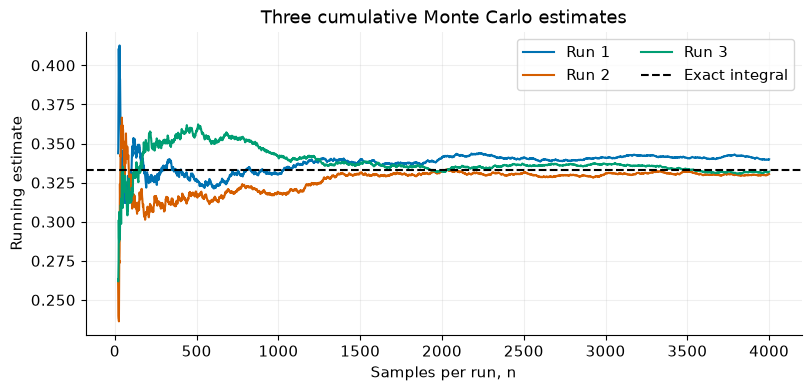

In [9]:
plt.rcParams.update(
    {"font.size": 11, "axes.spines.top": False, "axes.spines.right": False}
)
rng_paths = np.random.default_rng(2407)
path_size = 4000
# 三行独立采样，每行沿列累计 x²，再除以已使用的样本数。
path_values = rng_paths.random((3, path_size)) ** 2
sample_counts = np.arange(1, path_size + 1)
running_estimates = np.cumsum(path_values, axis=1) / sample_counts

fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
# 仅略去最初 19 个点以便观察；后续累计估计仍使用此前全部样本。
for index, color in enumerate(["#0072B2", "#D55E00", "#009E73"]):
    ax.plot(
        sample_counts[19:],
        running_estimates[index, 19:],
        color=color,
        label=f"Run {index + 1}",
    )
ax.axhline(1 / 3, color="black", linestyle="--", label="Exact integral")
ax.set(
    xlabel="Samples per run, n",
    ylabel="Running estimate",
    title="Three cumulative Monte Carlo estimates",
)
ax.legend(ncol=2)
ax.grid(alpha=0.2)
# 本次三条累计积分估计在 1/3 虚线附近波动；样本增多不意味着每一步误差都减小。
plt.show()

为了比较估计量的波动，对每个 n 独立重复 R 次；记第 r 次结果为 Îₙ,ᵣ，其中 r=1,…,R。已知真值 I 时，经验均方根误差为

$$\mathrm{RMSE}_{n,R}=\sqrt{\frac1R\sum_{r=1}^R(\widehat I_{n,r}-I)^2}。$$

本例无偏，理论 RMSE 为 √(4/(45n))。R 有限时，经验 RMSE 本身也有随机误差。下列四组实验分别使用 n=100、400、1600、6400，每组 R=800；每一行代表一次实验，每一列代表该实验中的一个样本。

In [10]:
rng_many = np.random.default_rng(2408)
sizes = np.array([100, 400, 1600, 6400])
repetitions = 800
empirical_rmse = []
for size in sizes:
    values = rng_many.random((repetitions, size)) ** 2
    estimates = values.mean(axis=1)
    errors = estimates - 1 / 3
    rmse = np.sqrt(np.mean(errors**2))
    empirical_rmse.append(rmse)
    # 本次 RMSE 约 0.03033、0.01558、0.00718、0.00353；与各自理论值比较，保留模拟波动。
    print(
        f"n={size:4d}，R={repetitions}：偏差均值={errors.mean():.6f}，RMSE={rmse:.6f}，理论={np.sqrt(4 / (45 * size)):.6f}"
    )
# 比较整体尺度，而不是要求每个有限模拟结果等于理论值。

n= 100，R=800：偏差均值=0.000557，RMSE=0.030327，理论=0.029814
n= 400，R=800：偏差均值=-0.000343，RMSE=0.015583，理论=0.014907
n=1600，R=800：偏差均值=0.000109，RMSE=0.007176，理论=0.007454
n=6400，R=800：偏差均值=-0.000088，RMSE=0.003526，理论=0.003727


## 7 精度与样本成本

理论标准误随 n⁻¹ᐟ² 缩小：将其减半，需要把 n 乘以 4。对于单次函数求值成本近似固定的直接采样方法，函数求值次数随 n 线性增加。这里统计求值次数，不将它冒充机器耗时实测。

增加 R 改善对重复实验分布的观察，不改变每次 n 个样本的估计精度。若把 R 组共 Rn 个独立样本的估计再平均，才构成更大总样本量的另一个估计量。二维对数图中的斜率 −1/2 表示理论误差缩放，常数仍由被积函数方差决定。

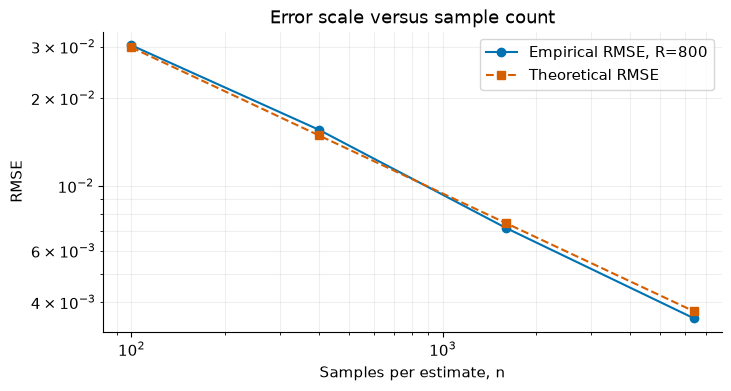

各组实验的函数求值次数： [  80000  320000 1280000 5120000]
总求值次数： 6800000
样本量四倍时的理论标准误比： [0.5 0.5 0.5]


In [11]:
theoretical_rmse = np.sqrt(4 / (45 * sizes))
fig, ax = plt.subplots(figsize=(7.2, 3.8), layout="constrained")
ax.loglog(sizes, empirical_rmse, "o-", color="#0072B2", label="Empirical RMSE, R=800")
ax.loglog(sizes, theoretical_rmse, "s--", color="#D55E00", label="Theoretical RMSE")
ax.set(
    xlabel="Samples per estimate, n",
    ylabel="RMSE",
    title="Error scale versus sample count",
)
ax.grid(alpha=0.2, which="both")
ax.legend()
# 本次经验 RMSE 接近理论线；样本量每增加到四倍，理论 RMSE 变为一半。
plt.show()
print("各组实验的函数求值次数：", repetitions * sizes)  # 预期为 [ 80000 320000 1280000 5120000]。
print("总求值次数：", repetitions * sizes.sum())  # 预期为 6800000。
print("样本量四倍时的理论标准误比：", theoretical_rmse[1:] / theoretical_rmse[:-1])  # 预期约为 [0.5 0.5 0.5]。

稀有事件说明：样本标准误很小未必意味着可信。设目标概率 p=10⁻⁴，令 Y 为事件指示变量，取值为 0 或 1。n=1000 次独立抽样全部未命中的概率为 (1−p)ⁿ，约为 0.90。

全部为零时，样本均值和样本标准差都为零，但真实标准误 √(p(1−p)/n) 大于零。此时不宜用退化的正态近似区间声明概率已精确算出。

In [12]:
rng_rare = np.random.default_rng(2409)
rare_probability = 1e-4
rare_n = 1000
rare_hits = rng_rare.random(rare_n) < rare_probability
print("理论未命中概率：", (1 - rare_probability) ** rare_n)  # 预期约为 0.904833。
print("实际命中次数：", rare_hits.sum())  # 本次固定种子下命中次数为 0，并不表示事件的理论概率为 0。
# 本次零命中使样本概率与样本标准误估计都为 0；与非零理论标准误比较。
print(
    "样本概率与估计标准误：", rare_hits.mean(), rare_hits.std(ddof=1) / np.sqrt(rare_n)
)
print("理论标准误：", np.sqrt(rare_probability * (1 - rare_probability) / rare_n))  # 预期约为 0.000316212。
# 固定种子的本次输出与公式分别核对；未命中不是概率为零的证据。

理论未命中概率： 0.9048328935585562
实际命中次数： 0
样本概率与估计标准误： 0.0 0.0
理论标准误： 0.00031621195423323263


## 8 综合计算一个非单位区间的积分

计算 I=∫₀²exp(−x)dx=1−exp(−2)，输入和输出均无量纲。取 U∼Uniform(0,2)，令 Y=2exp(−U)，则 E[Y]=I。把区间长度直接放入 Y，均值、标准误和区间便可围绕同一数组计算。

再独立重复 R=1000 次，每次 n=2000，比较经验 RMSE 与解析值。这里 E[Y²]=1−exp(−4)，故 Var(Y)=1−exp(−4)−I²。有限实验用于核对程序和观察随机误差，解析式才是本例的数学依据。

In [13]:
rng_application = np.random.default_rng(2410)
application_n = 2000
application_repetitions = 1000
application_exact = 1 - np.exp(-2)
application_samples = rng_application.uniform(0, 2, size=application_n)
# 均匀采样区间长度为 2，因此函数值乘 2 后再求平均来估计积分。
application_values = 2 * np.exp(-application_samples)
application_estimate = application_values.mean()
application_se = application_values.std(ddof=1) / np.sqrt(application_n)
application_ci = application_estimate + np.array([-1.0, 1.0]) * 1.96 * application_se
# 解析值约 0.864665；本次固定种子估计约 0.872348，有符号误差约 +0.007684。
print(
    "解析值、估计值与本次误差：",
    application_exact,
    application_estimate,
    application_estimate - application_exact,
)
print("估计标准误与近似 95% 区间：", application_se, application_ci)  # 本次固定种子下约为 0.0108414 [0.851099 0.893598]。

# 二维数组每行是一场独立实验；沿列取均值，再跨实验统计 RMSE。
repeated_values = 2 * np.exp(
    -rng_application.uniform(0, 2, size=(application_repetitions, application_n))
)
repeated_estimates = repeated_values.mean(axis=1)
application_variance = 1 - np.exp(-4) - application_exact**2
print("经验 RMSE：", np.sqrt(np.mean((repeated_estimates - application_exact) ** 2)))  # 本次固定种子下约为 0.0109807。
print("理论 RMSE：", np.sqrt(application_variance / application_n))  # 预期约为 0.0108176。
# 复用一个生成器继续抽样；此处没有重建相同种子来重复首批数据。

解析值、估计值与本次误差： 0.8646647167633873 0.8723483536578276 0.007683636894440293
估计标准误与近似 95% 区间： 0.010841415442394553 [0.85109918 0.89359753]
经验 RMSE： 0.010980674861153115
理论 RMSE： 0.010817561848581153


## 9 选学：重要性采样

设目标仍为 μ=Eₚ[f(X)]=∫f(x)p(x)dx，其中 p 是已归一化的目标密度。选择一个便于采样的提议密度 q，并要求在 f(x)p(x) 非零的区域，q(x)>0；积分中的零测度端点不影响这个条件。另需 Eₚ[|f(X)|]<∞，且能够计算 p/q。

在支持条件成立时，把积分乘除以 q 可得

$$\mu=\int\frac{f(x)p(x)}{q(x)}q(x)\,dx
=E_q\!\left[\frac{f(X)p(X)}{q(X)}\right]。$$

从 q 独立抽取 n 个样本，令权重 w(x)=p(x)/q(x)，便得到重要性采样（importance sampling）估计 μ̂q=mean(f(Xᵢ)w(Xᵢ))。分母为 n，不能随意改为样本权重之和，那将成为另一种估计方法。改变抽样密度后，只平均 f(Xᵢ) 会改变目标。

In [14]:
# 小型离散例子同样可以用概率质量之比。
target_p = np.array([0.5, 0.3, 0.2])
proposal_q = np.array([0.2, 0.3, 0.5])
weights = target_p / proposal_q
print("各取值的权重：", weights)  # 预期约为 [2.5 1. 0.4]。
print("目标期望：", np.sum(durations * target_p))  # 预期约为 2.1。
print("改用 q 后，带权求和：", np.sum(durations * weights * proposal_q))  # 预期约为 2.1。
print("忘记权重后的期望：", np.sum(durations * proposal_q))  # 预期约为 3.3。
# 前两个期望相等；最后一个是在 q 下的另一目标。

各取值的权重： [2.5 1.  0.4]
目标期望： 2.1
改用 q 后，带权求和： 2.1
忘记权重后的期望： 3.3


对 ∫₀¹x²dx，目标密度 p(x)=1，选择 q(x)=2x（0<x<1）。其分布函数为 Fq(x)=x²。若 U 在 [0,1] 均匀分布，则 P(√U≤x)=P(U≤x²)=x²，所以 X=√U 可以生成 q 下的样本。

带权函数值为 x²/(2x)=x/2。在端点 x=0 处用其连续延拓值 0，代码直接使用化简后的表达式，避免浮点生成器抽到零时产生 0/0。

In [15]:
rng_importance = np.random.default_rng(2411)
importance_n = 2000
proposal_samples = np.sqrt(rng_importance.random(importance_n))
weighted_values = proposal_samples / 2
print("重要性采样估计：", weighted_values.mean())  # 本次固定种子下约为 0.331892。
print("按带权函数值计算的标准误：", weighted_values.std(ddof=1) / np.sqrt(importance_n))  # 本次固定种子下约为 0.00264867。
print("不加权的函数值平均：", np.mean(proposal_samples**2))  # 本次固定种子下约为 0.496704。
# 正确目标为 1/3；不加权时估计 E_q[X²]=1/2。

重要性采样估计： 0.33189181924158195
按带权函数值计算的标准误： 0.0026486706242272386
不加权的函数值平均： 0.4967043054987996


重要性采样不自动降低方差。若 ∫(fp)²/q dx 有限，带权函数值的方差为该积分减去 μ²，估计量方差再除以 n。

本例直接均匀采样的单项方差为 4/45；改用 q=2x 后，E_q[(X/2)²]=∫₀¹(x²/4)·2x dx=1/8，故方差为 1/8−1/9=1/72，理论方差比为 6.4。下面每种方法独立重复 1000 次、每次 500 个样本，在相同样本数量下比较。

理论方差比： 6.4
模拟方差比： 6.982630404435819
两个方法的平均估计： 0.3330070040856862 0.3335834299062094


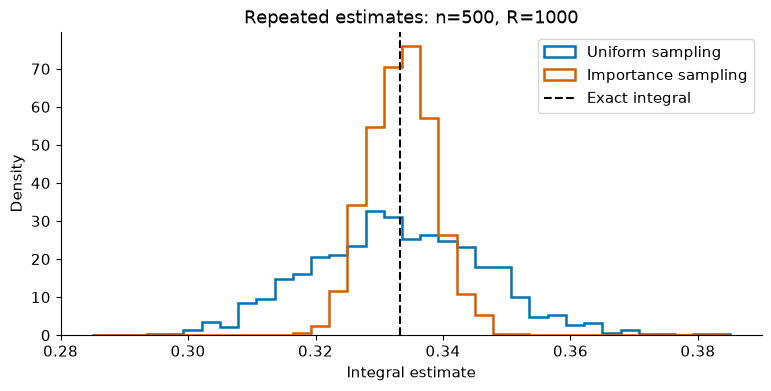

In [16]:
rng_comparison = np.random.default_rng(2412)
comparison_n = 500
comparison_r = 1000
# 行数是重复实验次数 R，列数是每次样本量 n；每行得到一个积分估计。
ordinary_estimates = (rng_comparison.random((comparison_r, comparison_n)) ** 2).mean(
    axis=1
)
# 按前面的推导用 sqrt(U) 从密度 2x 采样，加权后的函数值为 x/2。
importance_estimates = (
    np.sqrt(rng_comparison.random((comparison_r, comparison_n))) / 2
).mean(axis=1)
# 此处比较重复估计之间的方差，不是一次实验内的原始样本方差。
print("理论方差比：", (4 / 45) / (1 / 72))  # 预期约为 6.4。
print("模拟方差比：", ordinary_estimates.var(ddof=1) / importance_estimates.var(ddof=1))  # 本次固定种子下约为 6.98263。
print("两个方法的平均估计：", ordinary_estimates.mean(), importance_estimates.mean())  # 本次固定种子下约为 0.333007 0.333583。

# 两组估计共用分箱，轮廓直方图便于比较它们在真值附近的集中程度。
fig, ax = plt.subplots(figsize=(7.6, 3.8), layout="constrained")
bins = np.linspace(0.285, 0.385, 36)
ax.hist(
    ordinary_estimates,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color="#0072B2",
    label="Uniform sampling",
)
ax.hist(
    importance_estimates,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    color="#D55E00",
    label="Importance sampling",
)
ax.axvline(1 / 3, color="black", linestyle="--", label="Exact integral")
ax.set(
    xlabel="Integral estimate",
    ylabel="Density",
    title="Repeated estimates: n=500, R=1000",
)
ax.legend()
# 本次两组都集中在 1/3 附近，重要性采样直方图更窄；这是当前提议分布的对照结果。
plt.show()

## 10 选学：支持与权重的边界

若 q 只在 (1/2,1) 上均匀分布，其密度为 2。虽然每次样本都能计算 x²/2，但 q 完全漏掉了 (0,1/2) 的贡献，带权均值的期望只有 ∫₁⁄₂¹x²dx=7/24，少了 1/24。增加样本数不能修正这种支持不匹配。

In [17]:
rng_missing = np.random.default_rng(2413)
incomplete_samples = rng_missing.uniform(0.5, 1, size=20000)
incomplete_estimate = np.mean(incomplete_samples**2 / 2)
print("缺失支持时的估计：", incomplete_estimate)  # 本次固定种子下约为 0.292959。
print("该估计实际趋向的值：", 7 / 24)  # 该估计的理论目标为 7/24，约 0.291667。
print("真正目标与遗漏贡献：", 1 / 3, 1 / 24)  # 完整目标为 1/3，遗漏贡献为 1/24，分别约为 0.333333、0.041667。
# 样本中没有下半区间的信息，权重无法补出未覆盖区域的积分。

缺失支持时的估计： 0.2929590681831981
该估计实际趋向的值： 0.2916666666666667
真正目标与遗漏贡献： 0.3333333333333333 0.041666666666666664


支持充分也不保证方差有限。令目标 p(x)=1、f(x)=1（0<x<1），目标期望为 1；选择 q(x)=3x²。带权值为 1/(3x²)，其期望仍为 1，但二阶矩为

$$\int_0^1\frac{1}{9x^4}\,3x^2\,dx
=\int_0^1\frac{1}{3x^2}\,dx=\infty。$$

接近零的罕见样本会带来很大权重。此时不能套用有限方差的标准误缩放与正态区间。下面核对截去 (0,δ) 后的二阶矩 (1/δ−1)/3，δ>0；它随 δ 趋零而增大。这是解析发散的数值展示，不是用有限模拟证明无穷大。

In [18]:
cutoffs = np.array([1e-1, 1e-2, 1e-3, 1e-4])
truncated_second_moments = (1 / cutoffs - 1) / 3
for cutoff, moment in zip(cutoffs, truncated_second_moments):
    print(f"下界 δ={cutoff:.4f}，截断二阶矩={moment:.3f}")  # 截断二阶矩依次为 3、33、333、3333，随着下界靠近 0 持续增大。
# 普通均匀采样 f=1 时方差为零，错误的提议分布却会引入无限方差。

下界 δ=0.1000，截断二阶矩=3.000
下界 δ=0.0100，截断二阶矩=33.000
下界 δ=0.0010，截断二阶矩=333.000
下界 δ=0.0001，截断二阶矩=3333.000


## 本章小结

（1）先把目标写成期望，再明确采样分布和需要平均的函数值。积分中的区间长度、重要性采样中的权重都必须与公式一致。

（2）在独立同分布且函数值方差有限的条件下，估计量方差为单项方差除以 n。标准误是重复计算的波动尺度，不是某次误差的上界。

（3）样本量 n 决定单次估计的精度，重复次数 R 决定对这种波动的观察精度。相同种子重放数据不能替代新实验。

（4）重要性采样需要覆盖目标贡献区域；提议密度过小时，权重可能使方差变大或发散。

理解自查：为什么计算 E[X²] 时不能使用 X 的标准差来估计蒙特卡洛标准误？为什么一次实验的标准差为零，仍可能遗漏稀有事件？

## 练习

（1）仍取耗时 1、2、5 秒，但将概率改为 0.2、0.5、0.3。估计任务耗时至少为 2 秒的概率，先手算真值，再用 5000 个样本计算指示变量均值与标准误。说明标准误应该对哪个数组计算。

In [19]:
exercise_rng = np.random.default_rng(2421)
exercise_durations = np.array([1.0, 2.0, 5.0])
exercise_probabilities = np.array([0.2, 0.5, 0.3])
# 生成样本，将“至少 2 秒”转为布尔数组，再比较理论概率与估计。

（2）计算 ∫₂⁵x dx。写出均匀采样下的积分估计和标准误，使用 2000 个样本核对解析答案。再故意省略区间长度，解释扩大样本量为什么仍然得不到目标积分。

In [20]:
exercise_integral_rng = np.random.default_rng(2422)
exercise_lower, exercise_upper = 2.0, 5.0
exercise_size = 2000
# 先求解析积分，再比较带长度因子和不带长度因子的结果。

（3）对 ∫₀¹x²dx，比较方案 A 的 n=100、R=1000 和方案 B 的 n=1000、R=100。两者总求值次数相同。分别比较单次估计的 RMSE，以及 R 次估计再平均后的理论标准误；解释它们回答的问题为何不同。

In [21]:
exercise_budget_rng = np.random.default_rng(2423)
exercise_schemes = [(100, 1000), (1000, 100)]
# 每行代表一次实验。先保留各行估计，再观察跨行平均；不要每行重建相同种子。

（4）选学：目标改为 ∫₀¹x dx，仍用 q(x)=2x 采样。先化简带权函数值，再计算其方差。说明端点 x=0 的处理，以及为什么这次不需要依赖大样本就能得到相同估计值。若 q 只覆盖 (1/2,1)，结论是否仍成立？

In [22]:
exercise_importance_rng = np.random.default_rng(2424)
exercise_proposal_samples = np.sqrt(exercise_importance_rng.random(20))
# 化简 f*p/q 后计算，不直接在可能为零的端点做 0/0。
# 判断支持条件变化后，缺失区域对目标积分的贡献。

## 练习提示与解析

以下对应练习（4）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：在提议密度为正的区间先化简比值，再考虑端点。

提示 2：覆盖不到的区域若仍有非零积分贡献，权重无法补回这部分。

### 练习（4）参考解析

在 $0<x<1$ 上，带权值为 $x/(2x)=1/2$，因此每个样本都贡献 1/2，估计量方差为零，任意正样本数都给出积分 $1/2$。可将零端点处的化简结果延拓为 1/2，避免代码计算 0/0；该单点不改变连续积分。

若提议只覆盖 $(1/2,1)$，就漏掉 $\int_0^{1/2}x\,dx=1/8$。无论在已覆盖区域采多少点，带权估计的期望只对应已覆盖区域的积分 $3/8$，无法由此恢复目标 $1/2$；支撑覆盖条件失效。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Deep Learning 作者网站 | Goodfellow、Bengio、Courville，[Chapter 17 Monte Carlo Methods](https://www.deeplearningbook.org/contents/monte_carlo.html)，§17.1.2、式 17.1–17.7，期望、样本平均、有限方差条件及估计量方差；§17.2、式 17.8–17.12，改变采样密度后的权重和方差。 |
| Radboud University | Timothy Budd，[Monte Carlo Techniques §3.2](https://hef.ru.nl/~tbudd/mct/lectures/monte_carlo_integration.html#monte-carlo-integration-direct-sampling)，§3.2.1 积分写成期望，§3.2.2 样本方差与大样本误差估计，§3.2.4 样本成本及误差缩放；本章区间和数值例子另行构造。 |
| Art B. Owen 作者网站 | [Monte Carlo Theory, Methods and Examples，Chapter 9](https://artowen.su.domains/mc/Ch-var-is.pdf)，§9.1、第 4–6 页，式 9.1–9.4、Theorem 9.1：支持条件、带权估计与有限方差条件；第 3 页稀有事件未被命中的问题；§9.2、第 8 页，按样本权重归一化与普通重要性采样的区别。 |
| NumPy 官方文档 | NumPy 2.5：[Compatibility policy](https://numpy.org/doc/stable/reference/random/compatibility.html)，随机流复现的构建、环境、方法顺序与形状条件；[Generator.random](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.random.html)，半开区间与 size；[Generator.uniform](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html)，密度、区间及浮点端点边界；[Generator.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)，p 与离散抽样；[std](https://numpy.org/doc/stable/reference/generated/numpy.std.html)，ddof 与样本方差。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)，累积估计曲线；[Axes.loglog](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.loglog.html)，双对数尺度；[Axes.hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html)，分箱、density 与 step 轮廓图。 |